## Dataset Information

- The dataset contains information about Movies and TV Shows available on Netflix.
It includes details such as title, director, cast, country, release year, rating, duration, and the date the content was added to the platform.

## Problem Statement
- Streaming platforms like Netflix host thousands of titles from different countries and genres.
Understanding the distribution of this content helps identify trends in content production, audience targeting, and platform growth.

### The objective of this analysis is to:

- Explore the distribution of Movies vs TV Shows

- Identify the most common content ratings

- Analyze content production by country

- Understand how content additions have changed over time

- Discover the most common genres available on Netflix

- This analysis helps provide insights into Netflix’s content strategy and market focus.

In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [ ]:
#Load Dataset
df = pd.read_csv("netflix_titles.csv")

In [ ]:
#Top 5 records
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
#Total number of columns and rows
df.shape

(8807, 12)

In [ ]:
#Total information of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
#check null values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [ ]:
#Fill null values into unknown
df['director'].fillna('unknown',inplace = True)

In [ ]:
#Fill null values into unknown
df['cast'].fillna('unknown',inplace = True)



In [ ]:
#Fill null values into unknown
df['country'].fillna('unknown',inplace = True)


In [ ]:
#Drop null values in data_added column 
df.dropna(subset = ['date_added'],inplace = True)

In [ ]:
#Check Unique value in rating
df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', '74 min', '84 min', '66 min', 'NR', nan,
       'TV-Y7-FV', 'UR'], dtype=object)

In [ ]:
#Check null values
df.isnull().sum()

show_id           0
type              0
title             0
director          0
cast            825
country         831
date_added       10
release_year      0
rating            4
duration          3
listed_in         0
description       0
dtype: int64

In [ ]:
#Put only valid ratings
valid_ratings = ['TV-Y','TV-Y7','TV-G','TV-PG','TV-14','TV-MA','G','PG','PG-13','R','NC-17','NR','UR']
df['rating'] = df['rating'].where(df['rating'].isin(valid_ratings))

In [ ]:
#Fill null values into unknown so the dataset remain stable
df['rating'].fillna('unknown',inplace = True)

In [ ]:
#Drop unwanted column
df.drop('duration',axis = 1,inplace = True)

In [ ]:
#Check Null
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
listed_in       0
description     0
dtype: int64

In [55]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,"September 25, 2021",2020,PG-13,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,"September 24, 2021",2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,unknown,"September 24, 2021",2021,TV-MA,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
#To find duplicates value in dataset
df.duplicated().sum()

np.int64(0)

In [ ]:
#Convert date_added column into DateTime
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'])



In [71]:
df['Day_added'] = df['date_added'].dt.day
df['Month_added'] = df['date_added'].dt.month
df['Year_added'] = df['date_added'].dt.year

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8797 non-null   object        
 1   type          8797 non-null   object        
 2   title         8797 non-null   object        
 3   director      8797 non-null   object        
 4   cast          8797 non-null   object        
 5   country       8797 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8797 non-null   int64         
 8   rating        8797 non-null   object        
 9   listed_in     8797 non-null   object        
 10  description   8797 non-null   object        
 11  Day_added     8797 non-null   int32         
 12  Month_added   8797 non-null   int32         
 13  Year_added    8797 non-null   int32         
dtypes: datetime64[ns](1), int32(3), int64(1), object(9)
memory usage: 1.2+ MB


In [ ]:
#Drop unwanted column
df.drop('date_added',axis=1,inplace = True)

In [77]:
df.head()

,show_id,type,title,director,cast,country,release_year,rating,listed_in,description,Day_added,Month_added,Year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2020,PG-13,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,24,9,2021
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,unknown,2021,TV-MA,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",24,9,2021
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,24,9,2021


In [ ]:
#Make copy of the dataset
df_copy = df.copy()

### EDA

## Univariate Analysis

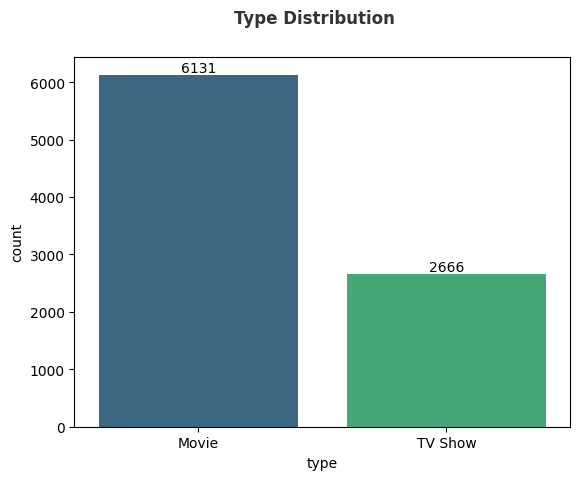

In [ ]:
#Type Distribution
df['type'].value_counts()
ax = sns.countplot(x = 'type',data = df_copy,palette = 'viridis')

for i in ax.containers:
    ax.bar_label(i)
plt.suptitle('Type Distribution',color = 'black',fontweight = 'bold',alpha = 0.8)   
plt.show()
    

### Observation
- Movies appear much more frequently than TV Show

### Insights
- Netflix focuses more on movies than TV Showa in its content library

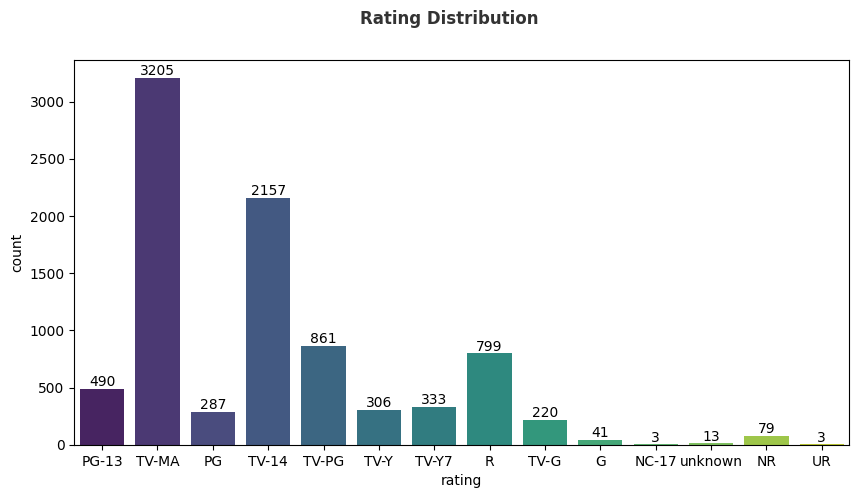

In [ ]:
#Rating Distribution
plt.figure(figsize = (10,5))

x = sns.countplot(x='rating',data = df_copy,palette = 'viridis')
for i in x.containers:
    x.bar_label(i)
plt.suptitle('Rating Distribution',color = 'black',fontweight = 'bold',alpha = 0.8)
plt.show()

### Observation
- TV-MA and TV-14 appear most frequently

### Insights
- Most content target teen and adults audiance

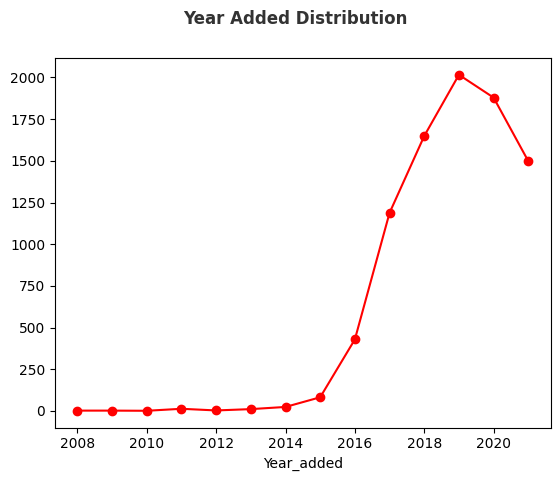

In [ ]:
#year Added Distribution
df_copy['Year_added'].value_counts().sort_index().plot(kind = 'line',color = 'red',marker = 'o')
plt.suptitle('Year Added Distribution',color = 'black',fontweight = 'bold',alpha = 0.8)
plt.show()

### Observation
- content increase sharply after 2026
### Insight
- Netflix expandad its global content strategy after 2016

## Bivariate Analysis

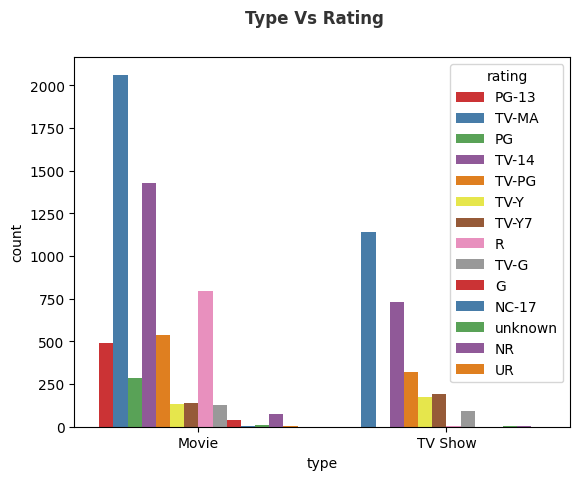

In [ ]:
#Type Vs Rating
sns.countplot(x = 'type',hue = 'rating',palette = 'Set1',data = df_copy)
plt.suptitle('Type Vs Rating',color = 'black',fontweight = 'bold',alpha = 0.8)
plt.show()

### Observation
- Mostly TV Show and Movie fall under TV-MA and YV-14
### Insight
- Netflix TV show and movie mainlt designed for mature and teenager audiance

In [ ]:
#Split countries Name
df_copy['country'] = df_copy['country'].str.split(',').str[0]

In [131]:
df_copy.head(1)

,show_id,type,title,director,cast,country,release_year,rating,listed_in,description,Day_added,Month_added,Year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2020,PG-13,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021


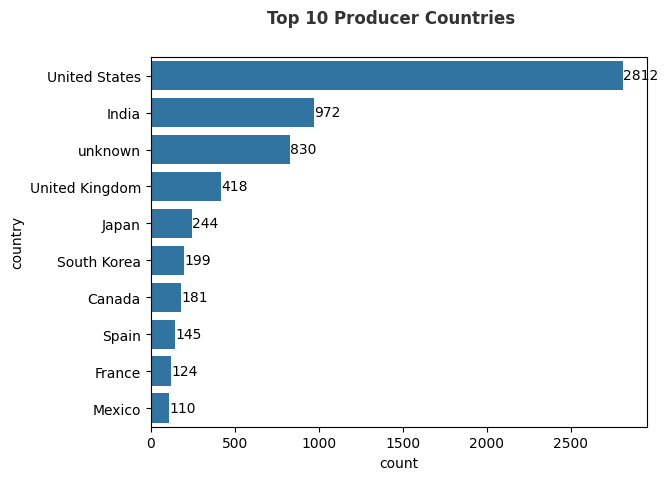

In [ ]:
#Top 10 Producer countries
ax = sns.countplot(y = 'country',data = df,order = df['country'].value_counts().index[:10])
for i in ax.containers:
    ax.bar_label(i)
plt.suptitle('Top 10 Producer Countries',color = 'black',fontweight = 'bold',alpha = 0.8)
plt.show()
    

### Observation
- The United States produces the most movies and TV shows on Netflix.
- India is also among the top content-producing countries.

### Insight
- The United States dominates Netflix’s content production, followed by countries like India and the United Kingdom, highlighting the platform’s strong presence in global entertainment markets.

## Trivariate Analysis

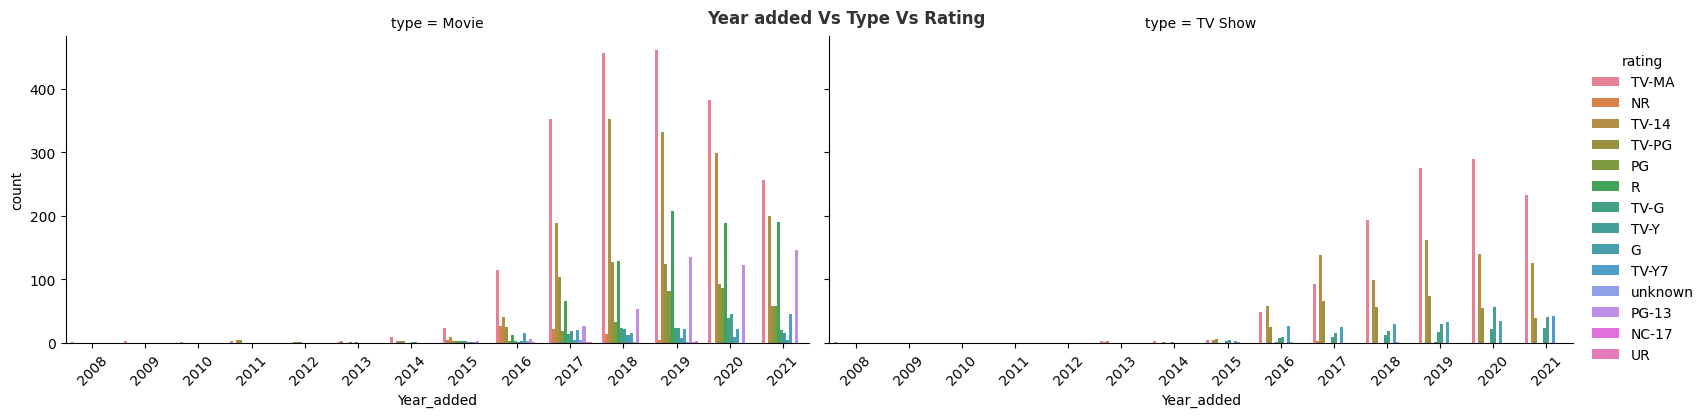

In [ ]:
#Year added Vs Type Vs Rating
x = sns.catplot(x = 'Year_added',hue= 'rating',col = 'type',data = df_copy,kind = 'count',height = 4,aspect=2)
x.set_xticklabels(rotation=45)
plt.suptitle('Year added Vs Type Vs Rating',color = 'black',fontweight = 'bold',alpha = 0.8)
plt.show()

### Observation
- Movies with TV-MA rating increased after 2017.
- TV Shows are mostly rated TV-14 and TV-MA.

### Insight
- Recent content additions on Netflix show a strong trend toward mature-rated entertainment.

## Final Conclusion
- The analysis shows that Netflix focuses heavily on movie content and mature-rated programming.Over the years, the platform has significantly expanded its content library, especially after 2016, aligning with its global growth strategy.

- The dominance of content from the United States highlights its strong influence in the entertainment industry, while the presence of international titles reflects Netflix’s effort to cater to a global audience.

- Overall, Netflix’s catalog emphasizes modern, diverse, and mature entertainment, which aligns with the viewing preferences of its worldwide subscriber base.



### Tools Used
- Python
- Pandas
- Seaborn
- Matplotlib
- Seaborn


